# Aggregate OGGM v1.6.3  raw files to regional or global summed up csv files (here by comparing different glacier projection options, and just looking at one GCM)

For OGGM v1.6.3, the default option is the same as in OGGM v1.6.1 (i.e. `1.6.3/w5e5/per_glacier_spinup`). However, we also provide additional test projection options under just one GCM (CMIP6 MRI-ESM2-0) which are aggregated in this notebook and analysed in [notebooks/1.6.3/analyse_csv_files_1.6.3_option_comparison_onegcm.ipynb](analyse_csv_files_1.6.3_option_comparison_onegcm.ipynb). 

Option overview:
- ERA5 instead of W5E5: `1.6.3/era5/per_glacier_spinup`
- regionally calibrated dynamical spinup instead of per-glacier dynamically calibrated spinup for RGI version 6.2 and RGI version 7.0: `1.6.3/w5e5/regional_spinup` 


*Note that the paths of this notebook only work if you are running the notebook from the OGGM cluster*


In [30]:
import xarray as xr
import pandas as pd
import progressbar
import numpy as np
from oggm.utils import mkdir
import matplotlib.pyplot as plt
import json
import os
import glob


_dirpath = '/home/www/oggm/oggm-standard-projections/oggm_v16/2025.6/'
_outputpath = '/home/www/oggm/oggm-standard-projections/oggm-standard-projections-csv-files/1.6.3'
oggm_version = 'oggm_v1.6.3_2025.6'
add='_only_one_gcm' # because just one GCM

# for OGGM v1.6.3, we only ran `w5e5_gcm_merged`  (or era5_gcm_merged)
# (i.e., w5e5/era5 until end of 2019, and the climate models from thereon)

In [31]:
%pwd

'/home/www/oggm/oggm-standard-projections/oggm-standard-projections-csv-files/notebooks/1.6.3'

In [32]:
# we ran this notebook once with rgi62 and once with rgi70
## new for OGGM v1.6.3 --> different experiments
options = []
for rgi_version in ['rgi62', 'rgi70G', 'rgi70C']:
    if rgi_version == 'rgi62':
        exps = ['per_glacier_spinup', # this is actually the same as "match_geod_pergla" of OGGM v1.6.1 (if the dynamic spinup gdirs are used)
                'regional_spinup']
    else:
        exps = ['regional_spinup']  # rgi70 does not yet have per-glacier geodetic hugonnet et al. data

    for exp in exps:
        if rgi_version == 'rgi62' and exp == 'per_glacier_spinup':
            clims = ['era5'] # we have already w5e5 with all GCMs
        else:
            clims = ['w5e5']   
        for baseline_climate in clims:
            options.append(f'{rgi_version}-{exp}-{baseline_climate}')
options

['rgi62-per_glacier_spinup-era5',
 'rgi62-regional_spinup-w5e5',
 'rgi70G-regional_spinup-w5e5',
 'rgi70C-regional_spinup-w5e5']

## A. Common running glacier aggregations for all projections (and options) until 2100, i.e. `common_running_2100`

### B. 1: GCMs - missing glaciers overview  

In [33]:
def create_missing_region_overview(option='rgi62-per_glacier_spinup-era5'): 
    rgi_version, exp, baseline_climate = option.split('-')
    print(rgi_version, exp, baseline_climate)
    historical_future_option = f'{baseline_climate}_gcm_merged'
    dirpath = _dirpath + f'{baseline_climate}/{exp}/'
    outputpath = _outputpath + f'/{baseline_climate}/{exp}'
    mkdir(outputpath + '/common_running_2100')
    
    # we are only interested in three ssps and only until 2100 for the comparison 
    allfiles = []
    for root, dirs, files in os.walk(dirpath):
        if not '/2300/' in root:
            for file in files:
                _p = os.path.join(root, file)
                if (('RGI2000-v7.0-G' in _p) and (rgi_version == 'rgi70G')) or (('RGI2000-v7.0-C' in _p) and (rgi_version == 'rgi70C')) or (('RGI2000-v7.0' not in _p) and (rgi_version == 'rgi62')):
                    if (file.endswith(".nc")) and ('run_hydro' in file) and (historical_future_option in file) and ('_0_1000' in file) and ('basin' not in file):
                        if ('ssp126' in _p) or ('ssp370' in _p) or ('ssp585' in _p):
                            allfiles.append(_p)      
    assert len(allfiles) == 3*19 # one gcm, three ssps, 19 regions

    
    if rgi_version == 'rgi62':
        rgi_meta = pd.read_hdf('/home/www/oggm/rgi/rgi62_stats.h5')
        rgi_meta = rgi_meta.loc[rgi_meta.Connect != 2]
    elif rgi_version == 'rgi70G':
        rgi_meta = pd.read_csv('/home/www/oggm/rgi/RGI2000-v7.0-G-global-attributes.csv')
        rgi_meta = rgi_meta.loc[rgi_meta.conn_lvl !=2]
        rgi_meta['O1Region'] = rgi_meta['o1region'].astype(str).str.zfill(2)
        rgi_meta['Area'] = rgi_meta['area_km2']
        rgi_meta = rgi_meta.set_index('rgi_id')
    elif rgi_version == 'rgi70C':
        rgi_meta = pd.read_csv('/home/www/oggm/rgi/RGI2000-v7.0-C-global-attributes.csv')
        #rgi_meta = rgi_meta.loc[rgi_meta.conn_lvl !=2]
        rgi_meta['O1Region'] = rgi_meta['o1region'].astype(str).str.zfill(2)
        rgi_meta['Area'] = rgi_meta['area_km2']
        rgi_meta = rgi_meta.set_index('rgi_id')
    
        
    df_meta = pd.DataFrame()
    invalid_per_reg = {}  
    meta_per_reg = {}

    # this takes very long !!!
    invalid_per_reg = {}  
    meta_per_reg = {}
    for f in allfiles: #progressbar.progressbar(allfiles):
        ename = f.replace(dirpath, '')
        ss = ename.split('/')
        cmip = ss[0]
        endyr = ss[1]
        rgi_reg = ss[2]
        gcm_original = ss[3].split('_')[5] 
        gcm = gcm_original.upper()
        if 'ISIMIP3b' in cmip:
            ssp = ss[3].split('_')[7]
            bc = 'ISIMIP3b:1979-2014'
        else:
            ssp = ss[3].split('_')[6]
            bc = '2000-2019'
    
        end0,end1 = ss[3].split('_')[-2:]
        end = end0+'_'+end1
        ff = f[:-len(end)]+'*'
    
        # exp is the same everywhere, so we don't need it as an id... 
        run_id = f'{cmip}:{endyr}:{gcm}:{ssp}:{rgi_reg}'
        df_meta.loc[run_id, 'cmip'] = cmip
        df_meta.loc[run_id, 'gcm_original'] = gcm_original # some have lower and upper cases in the raw output files
        df_meta.loc[run_id, 'gcm'] = gcm  # for the aggregated files, all GCMs are in upper cases
        df_meta.loc[run_id, 'scenario'] = ssp
        df_meta.loc[run_id, 'rgi_reg'] = rgi_reg
        df_meta.loc[run_id, 'end_year'] = 'nan'  # changed from 0 to this, to remove warning,--> will be filled later
        df_meta.loc[run_id, 'bias_correction'] = bc
        df_meta.loc[run_id, 'perc_area_missing'] = 0
        df_meta.loc[run_id, 'fpath'] = ff
        
        if rgi_reg not in invalid_per_reg:
            invalid_per_reg[rgi_reg] = set()
        
        if rgi_reg not in meta_per_reg:
            meta_per_reg[rgi_reg] = rgi_meta.loc[rgi_meta['O1Region'] == rgi_reg[-2:]]
        
        with xr.open_mfdataset(ff) as ds:
            ds_t = ds.isel(time=-1).volume.load()
        df_meta.loc[run_id, 'end_year'] = str(int(ds_t.time))
        missing_ids = ds_t.rgi_id[ds_t.isnull()].data
        perc = meta_per_reg[rgi_reg].loc[missing_ids]['Area'].sum() / meta_per_reg[rgi_reg]['Area'].sum() 
        df_meta.loc[run_id, 'perc_area_missing'] = perc
        invalid_per_reg[rgi_reg] = invalid_per_reg[rgi_reg].union(missing_ids)
        #if f == allfiles[100]:
        #    print(f)
    df_meta['exp'] = exp
    df_meta['historical_future_option'] = historical_future_option
    df_meta['oggm_version'] = oggm_version
    df_meta.to_csv(f'{outputpath}/common_running_2100/metadata_{rgi_version}{add}.csv')

    dds = df_meta.sort_values('perc_area_missing', ascending=False)
    print('regions with above 1% of glacier area missing:', dds[dds['perc_area_missing'] > 0.01].rgi_reg.unique())

    for k, v in invalid_per_reg.items():
        invalid_per_reg[k] = list(v)
    with open(f'{outputpath}/common_running_2100/rgi_ids_missing_{rgi_version}{add}.json', 'w') as f:
        json.dump(invalid_per_reg, f)
    
    # these are now the common running glaciers over all scenarios and GCMs and all cmip variants going until 2100 or until 2300
    odf = pd.DataFrame()
    for rgi_reg, missing_ids in invalid_per_reg.items():
        odf.loc[rgi_reg, 'n_glaciers'] = len(meta_per_reg[rgi_reg])
        odf.loc[rgi_reg, 'n_missing_glaciers'] = len(missing_ids)
        odf.loc[rgi_reg, 'rgi_area_km2'] = meta_per_reg[rgi_reg]['Area'].sum() 
        odf.loc[rgi_reg, 'missing_area_km2'] = meta_per_reg[rgi_reg].loc[missing_ids]['Area'].sum()
        odf.loc[rgi_reg, 'missing_area_perc'] = odf.loc[rgi_reg, 'missing_area_km2'] / odf.loc[rgi_reg, 'rgi_area_km2']
    odf[['n_glaciers', 'n_missing_glaciers']] = odf[['n_glaciers', 'n_missing_glaciers']].astype(int)
    odf = odf.sort_values(by='missing_area_perc', ascending=False)

    odf.to_csv(f'{outputpath}/common_running_2100/missing_region_overview_{rgi_version}{add}.csv')
    odf.to_html(f'{outputpath}/common_running_2100/missing_region_overview_{rgi_version}{add}.html')

In [34]:
for option in options:
    create_missing_region_overview(option=option)

rgi62 per_glacier_spinup era5
regions with above 1% of glacier area missing: ['RGI12' 'RGI10']
rgi62 regional_spinup w5e5
regions with above 1% of glacier area missing: ['RGI12' 'RGI10']
rgi70G regional_spinup w5e5
regions with above 1% of glacier area missing: []
rgi70C regional_spinup w5e5
regions with above 1% of glacier area missing: []


### B. 2: GCMs - aggregation

In [35]:
for option in options:
    rgi_version, exp, baseline_climate = option.split('-')
    print(rgi_version, exp, baseline_climate)
    outputpath = _outputpath + f'/{baseline_climate}/{exp}'
    base_dir =f'{outputpath}/common_running_2100'
    df_meta = pd.read_csv(f'{base_dir}/metadata_{rgi_version}{add}.csv', index_col = 0)

    if rgi_version == 'rgi62':
        rgi_meta = pd.read_hdf('/home/www/oggm/rgi/rgi62_stats.h5')
        rgi_meta = rgi_meta.loc[rgi_meta.Connect != 2]
    elif rgi_version == 'rgi70G':
        rgi_meta = pd.read_csv('/home/www/oggm/rgi/RGI2000-v7.0-G-global-attributes.csv')
        rgi_meta = rgi_meta.loc[rgi_meta.conn_lvl !=2]
        rgi_meta['O1Region'] = rgi_meta['o1region'].astype(str).str.zfill(2)
        rgi_meta['Area'] = rgi_meta['area_km2']
        rgi_meta = rgi_meta.set_index('rgi_id')
    elif rgi_version == 'rgi70C':
        rgi_meta = pd.read_csv('/home/www/oggm/rgi/RGI2000-v7.0-C-global-attributes.csv')
        #rgi_meta = rgi_meta.loc[rgi_meta.conn_lvl !=2]
        rgi_meta['O1Region'] = rgi_meta['o1region'].astype(str).str.zfill(2)
        rgi_meta['Area'] = rgi_meta['area_km2']
        rgi_meta = rgi_meta.set_index('rgi_id')
    
    with open(f'{base_dir}/rgi_ids_missing_{rgi_version}{add}.json', 'r') as f:
        invalid_per_reg = json.load(f)
    # for the csv files, we let them only run until beginning of 2100
    # to have something consistent
    df_meta.loc[df_meta.end_year==2101, 'end_year'] = 2100
    
    for cmip in df_meta.cmip.unique():
        print(cmip, flush=True)
        for end_year in [2100]:
            for rgi_reg in sorted(df_meta.rgi_reg.unique()): #progressbar.progressbar(
                for scenario in sorted(df_meta.loc[(df_meta.cmip==cmip) & (df_meta.end_year == end_year)].scenario.unique()):
                    df_meta_s = df_meta.loc[(df_meta.end_year == end_year) & (df_meta.cmip == cmip) & (df_meta.rgi_reg == rgi_reg) & (df_meta.scenario == scenario)]
                    odf_v = pd.DataFrame()
                    odf_a = pd.DataFrame()
                    ods = []
                    gcms = []
                    for i, s in df_meta_s.iterrows():
                        with xr.open_mfdataset(s.fpath) as ds:
                            # make sure that we only aggregate if all batch files are available
                            # could happen that one has not finished ... or did not run...
                            n_files = len(glob.glob(s.fpath))
                            assert np.ceil(len(rgi_meta.loc[rgi_meta.O1Region==rgi_reg[-2:]])/1000) == n_files
                            ds = ds[['volume', 'area']].load().isel(rgi_id=~ds.rgi_id.isin(invalid_per_reg[s.rgi_reg]))
                            # not look until year 2101
                            ds = ds.sel(time=slice(2000,end_year))
                            #ds = ds[['volume', 'area', 'length']].load().isel(rgi_id=~ds.rgi_id.isin(invalid_per_reg[s.rgi_reg]))
                            odf_v[s.gcm] = ds.volume.sum(dim='rgi_id').to_series()
                            odf_a[s.gcm] = ds.area.sum(dim='rgi_id').to_series()
                            ods.append(ds)
                            gcms.append(s.gcm)
                    ods = xr.concat(ods, 'gcm')
    
                    odir =  f'{base_dir}/volume/{cmip}/{end_year}/{rgi_reg}/'
                    mkdir(odir)
                    odf_v.to_csv(odir + f'{scenario}.csv')
                    odir = f'{base_dir}/area/{cmip}/{end_year}/{rgi_reg}/'
                    mkdir(odir)
                    odf_a.to_csv(odir + f'{scenario}.csv')
                    
    # globally: sum over all RGI regions
    for var in ['volume', 'area']:
        for cmip in df_meta.cmip.unique():
            if rgi_version == 'rgi62':
                odir = f'{base_dir}/{var}/{cmip}/{end_year}/global/'
            else:
                odir = f'{base_dir}/{var}/{cmip}/{end_year}/global_{rgi_version}/'
            mkdir(odir)
            for scenario in sorted(df_meta.loc[(df_meta.cmip==cmip) & (df_meta.end_year == end_year)].scenario.unique()):
                odf = 0
                for rgi_reg in sorted(df_meta.rgi_reg.unique()):
                    idir = f'{base_dir}/{var}/{cmip}/{end_year}/{rgi_reg}/'
                    df = pd.read_csv(idir + f'/{scenario}.csv', index_col=0)
                    odf += df
                odf.to_csv(odir + f'/{scenario}.csv')

rgi62 per_glacier_spinup era5
CMIP6
rgi62 regional_spinup w5e5
CMIP6
rgi70G regional_spinup w5e5
CMIP6
rgi70C regional_spinup w5e5
CMIP6


# Visualisation of missing common running glaciers

rgi62 per_glacier_spinup era5
rgi62 regional_spinup w5e5
rgi70G regional_spinup w5e5
rgi70C regional_spinup w5e5


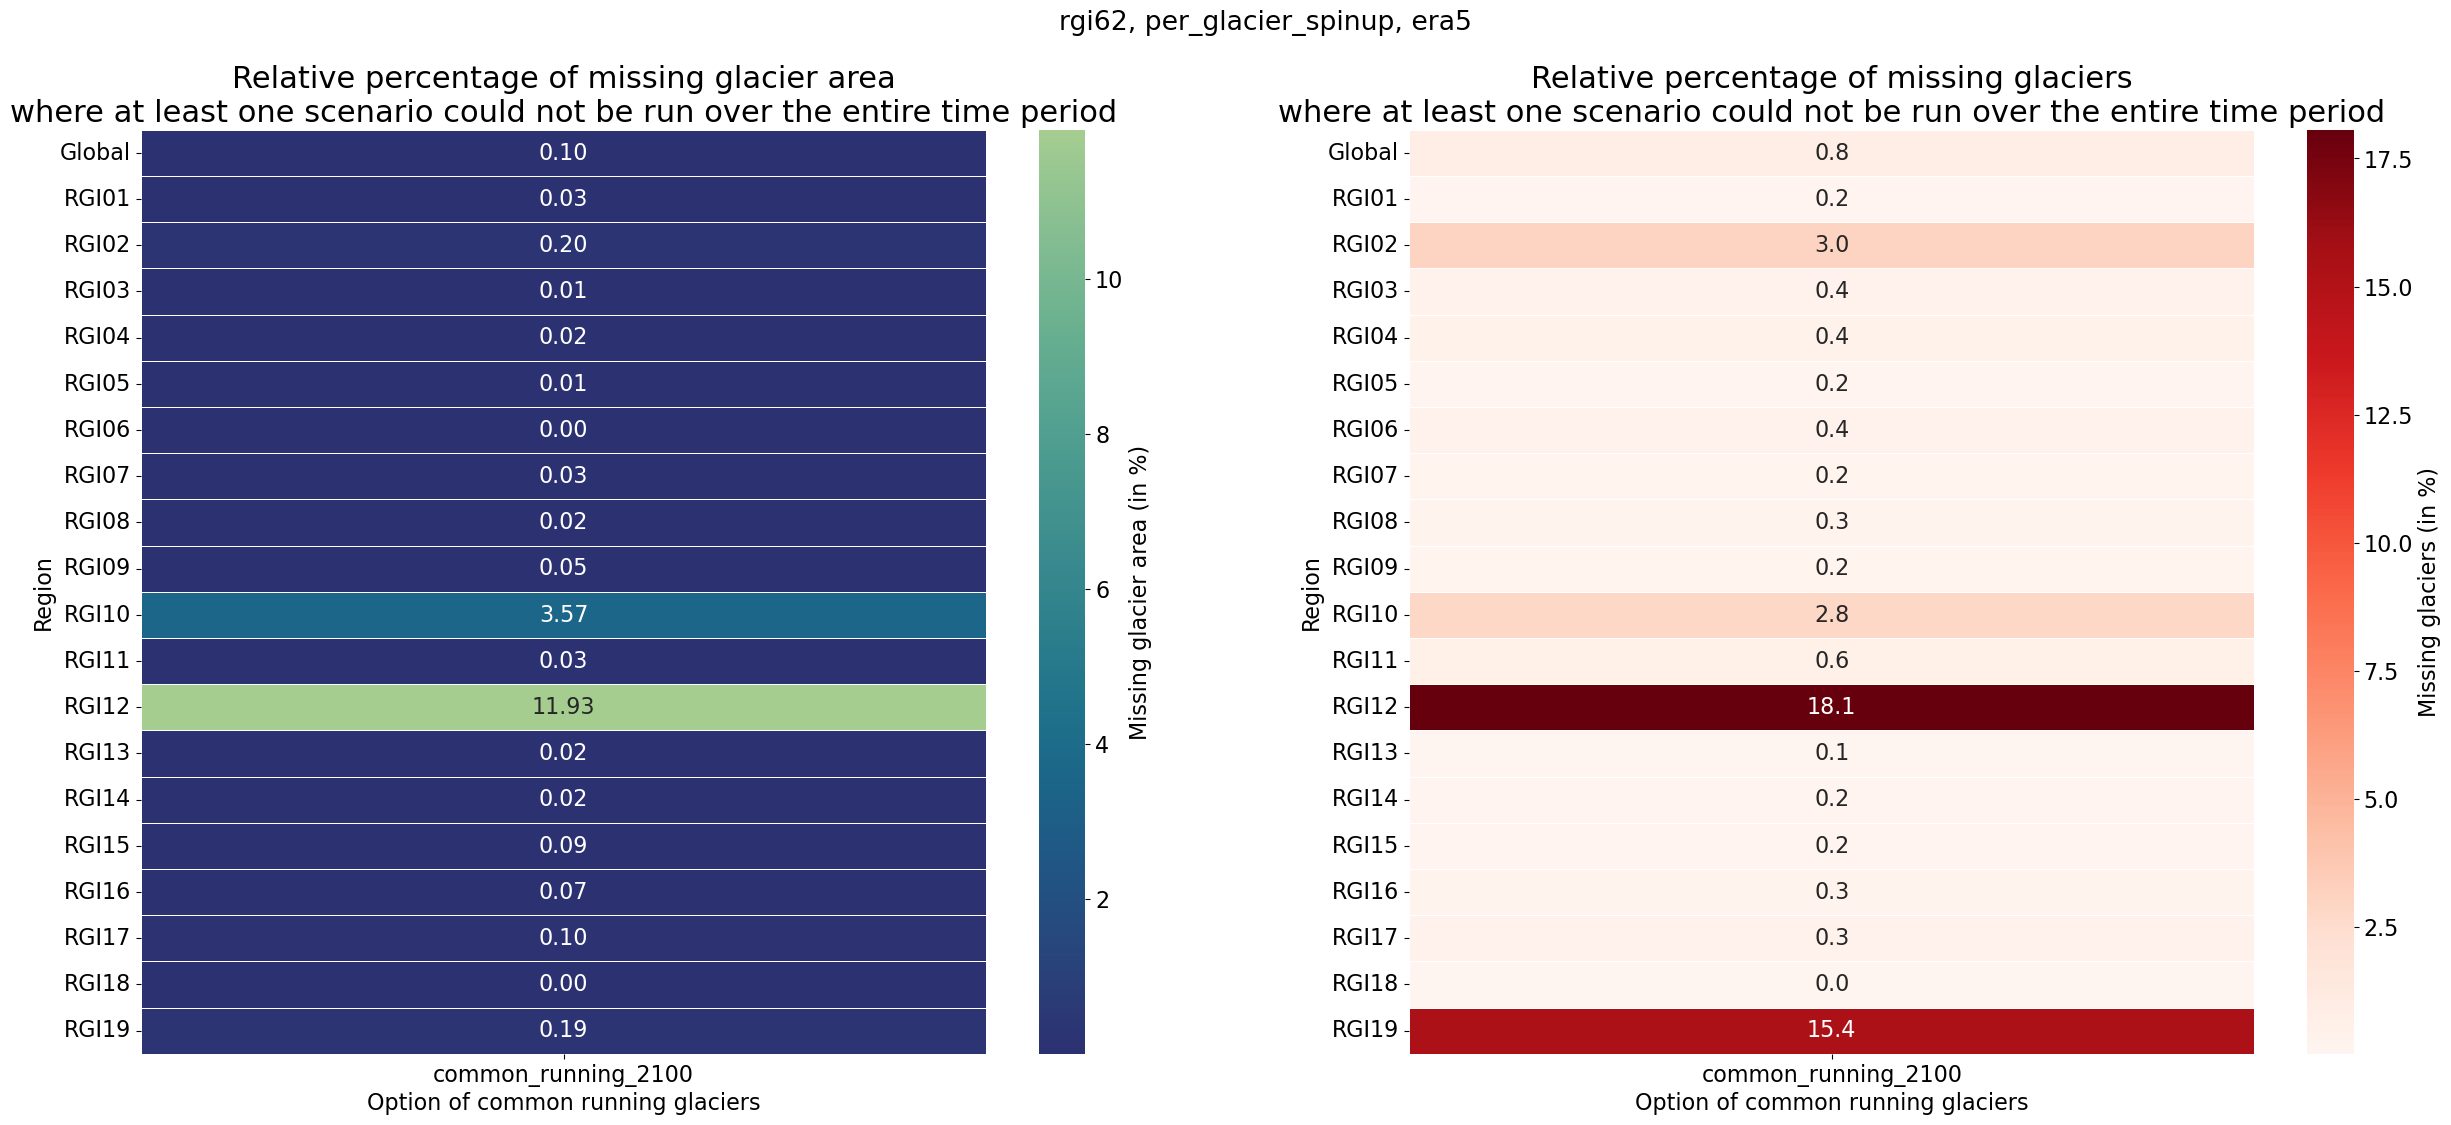

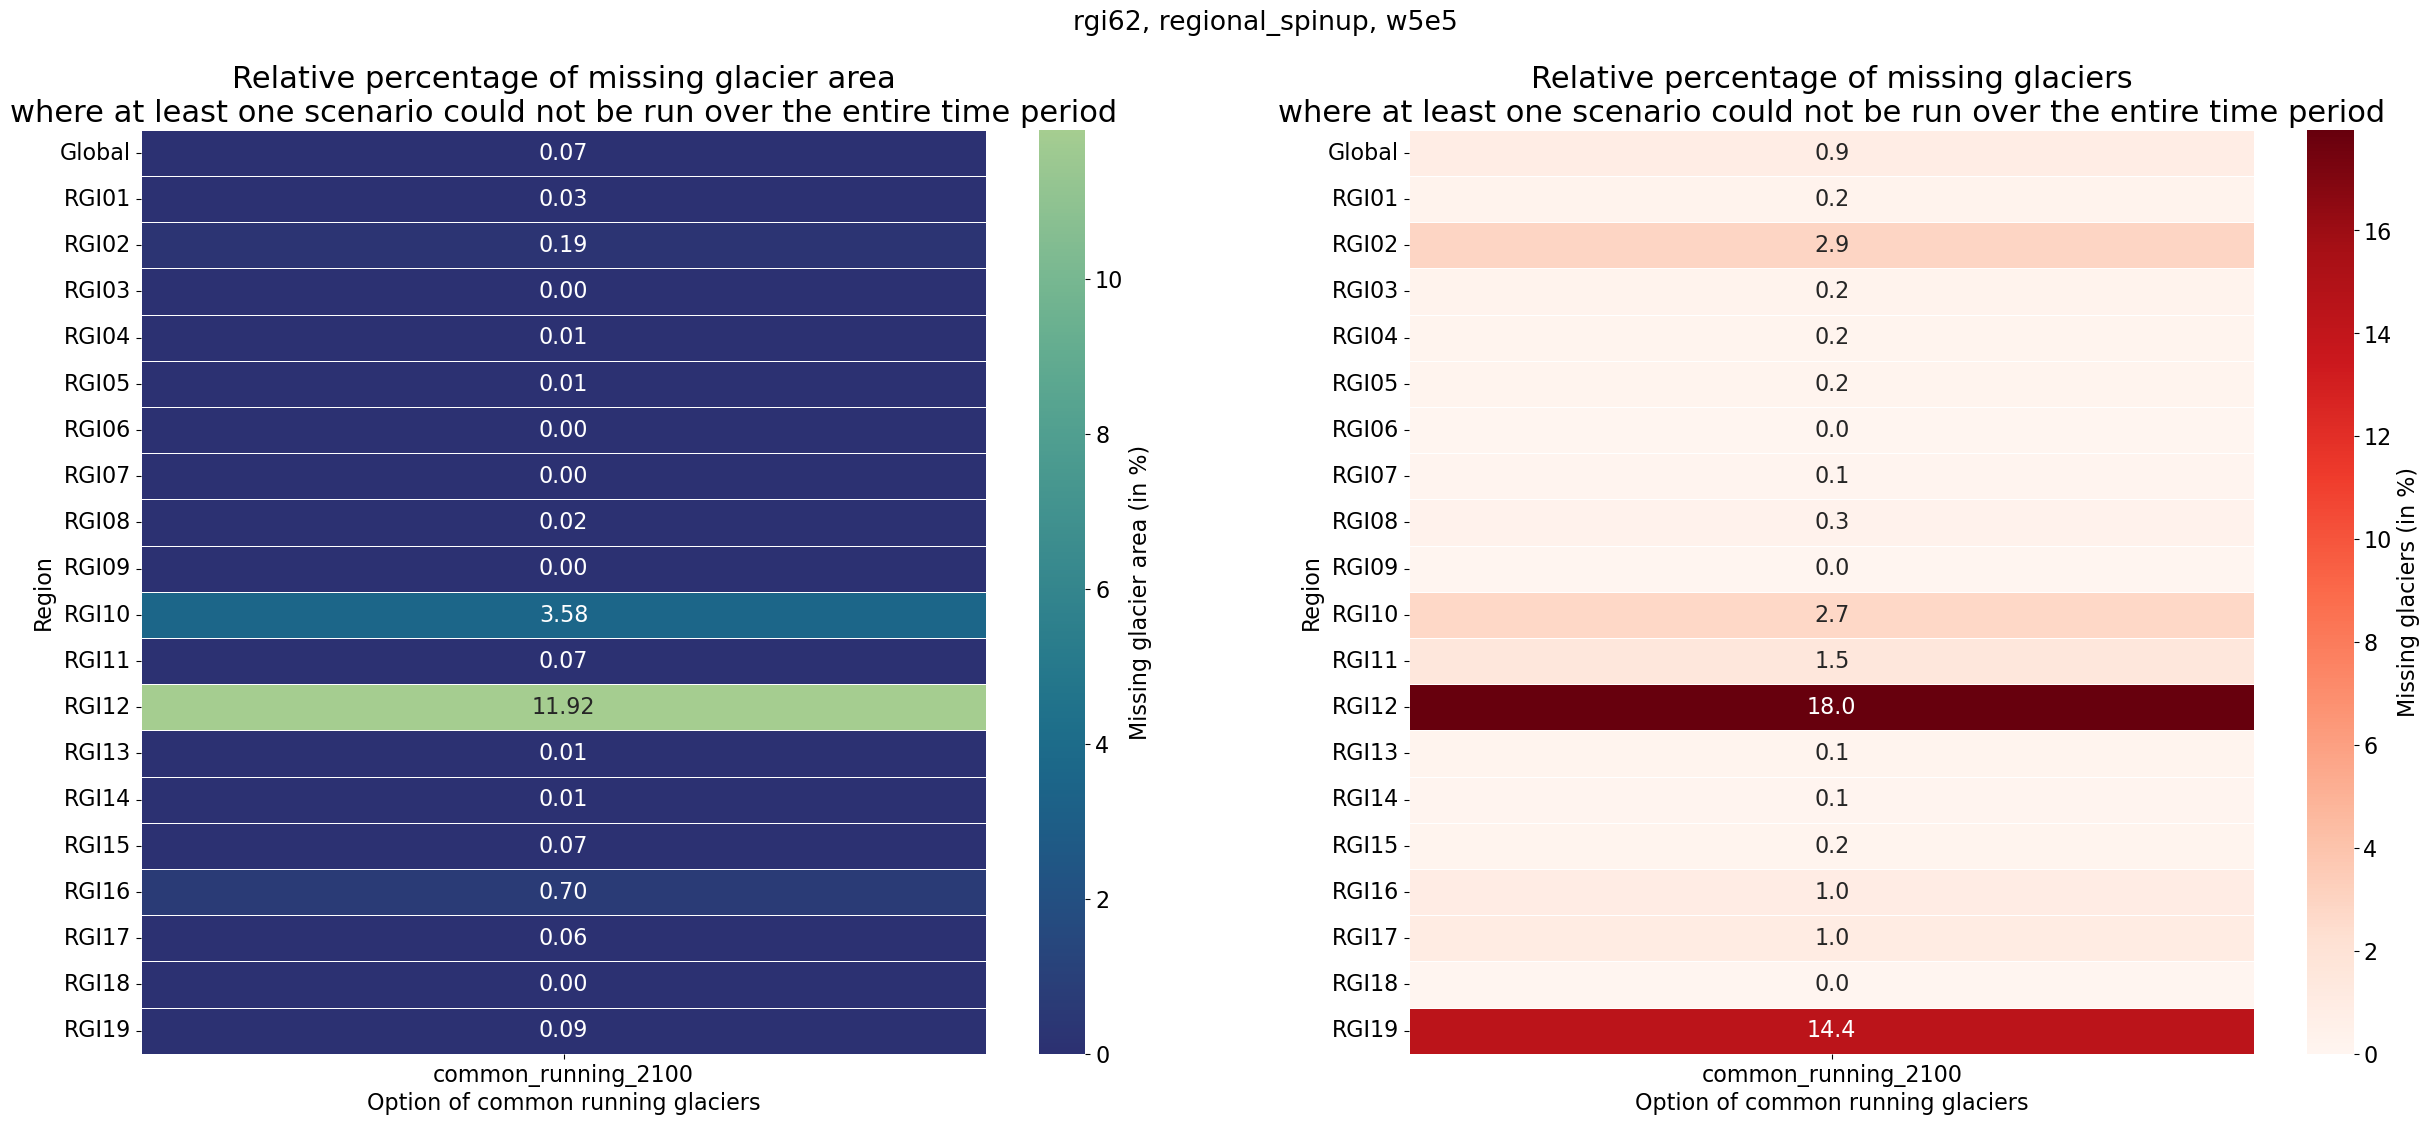

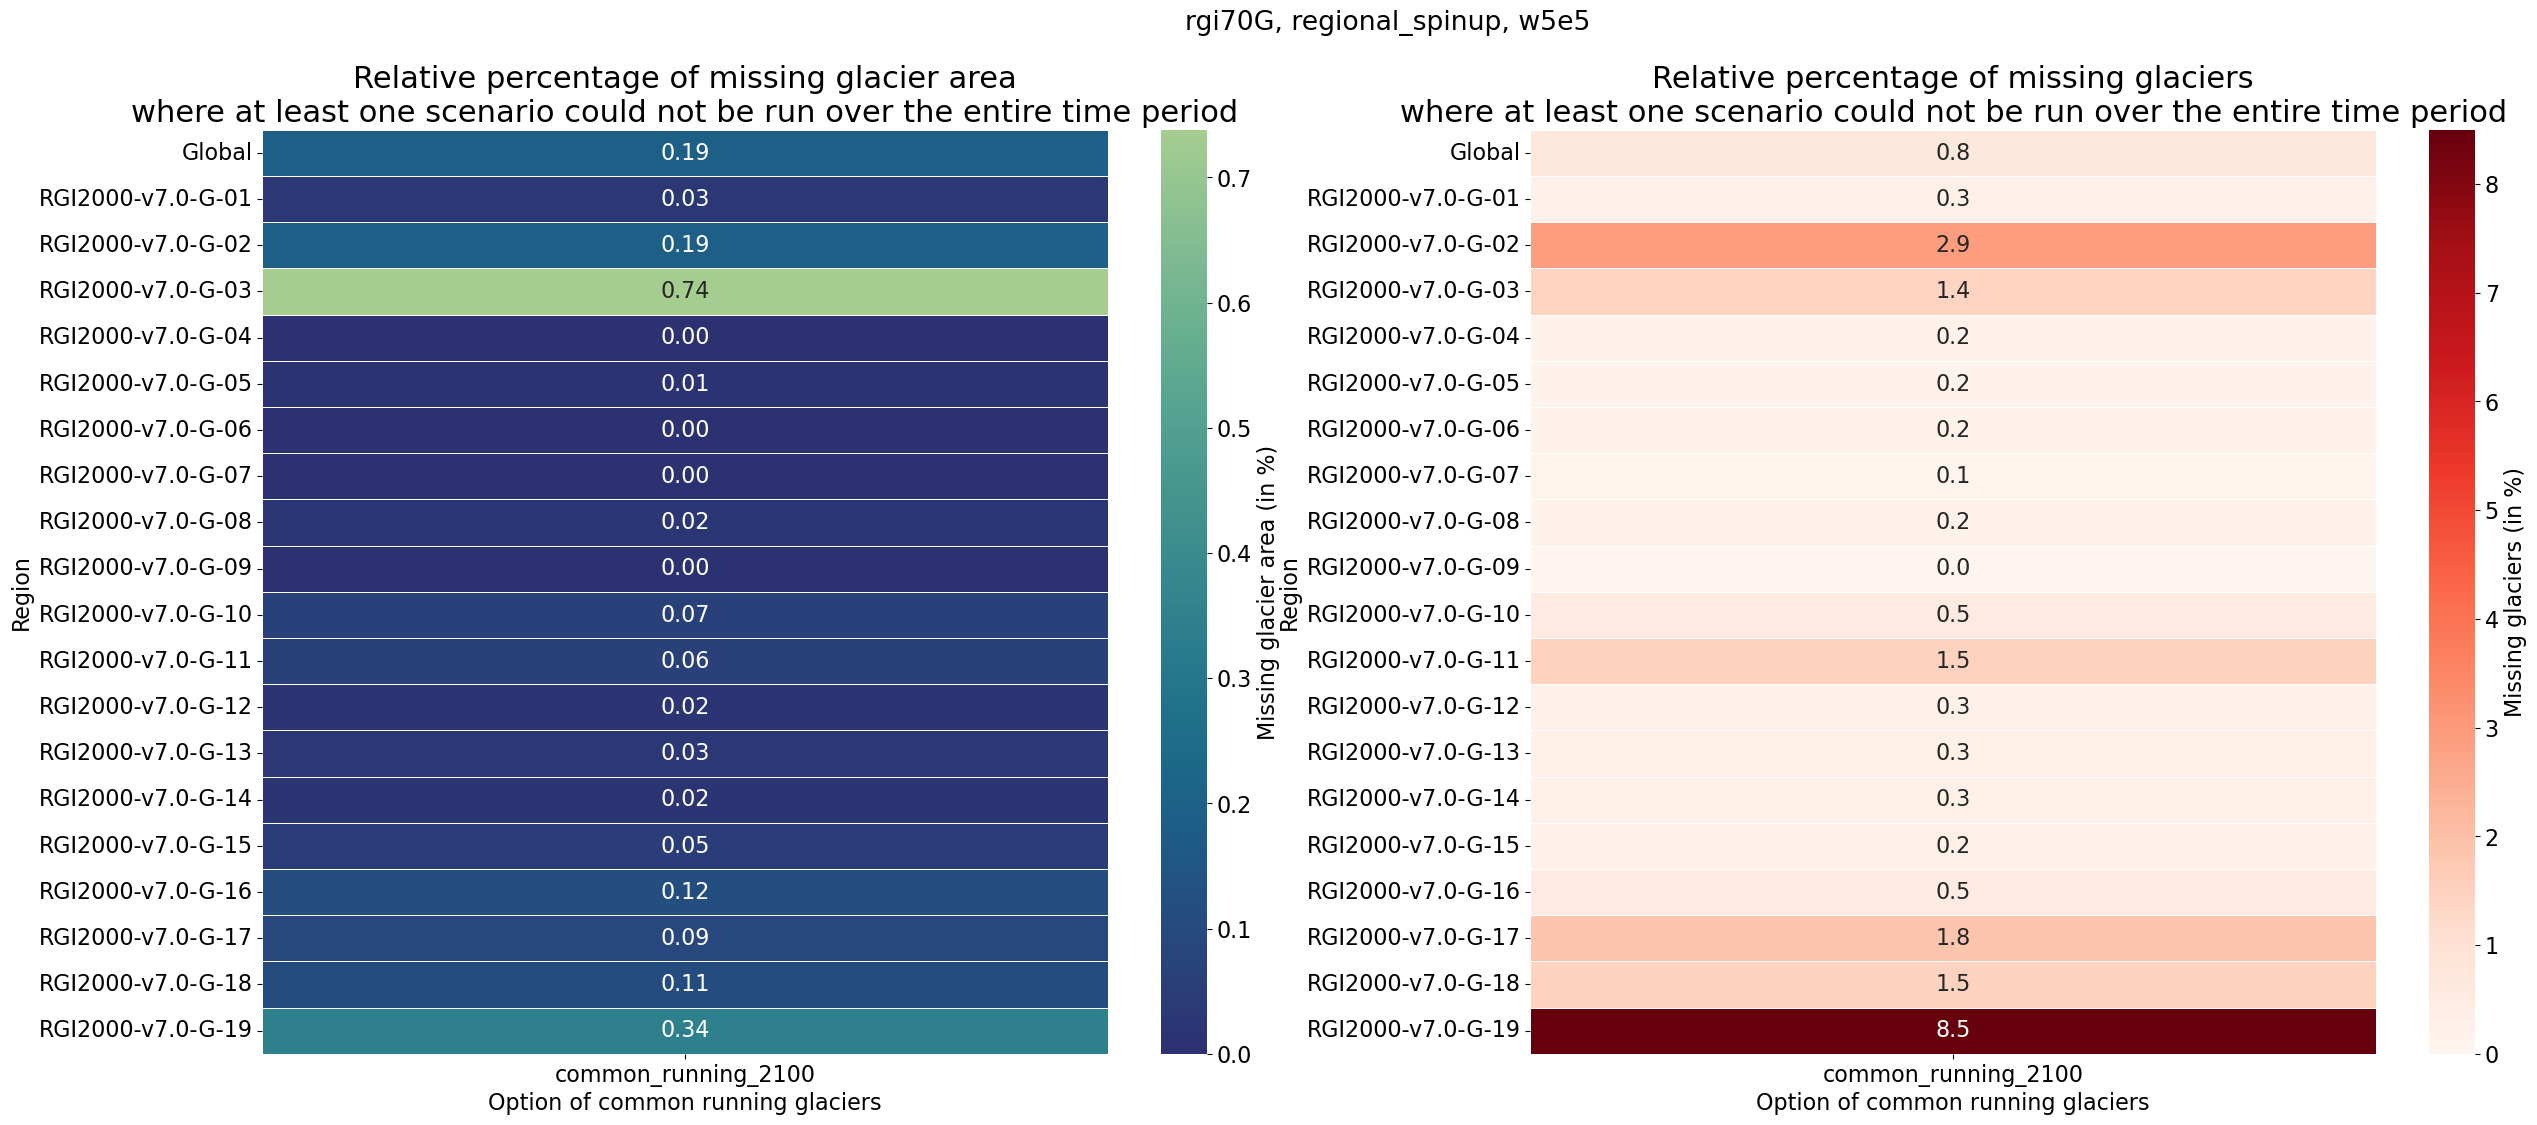

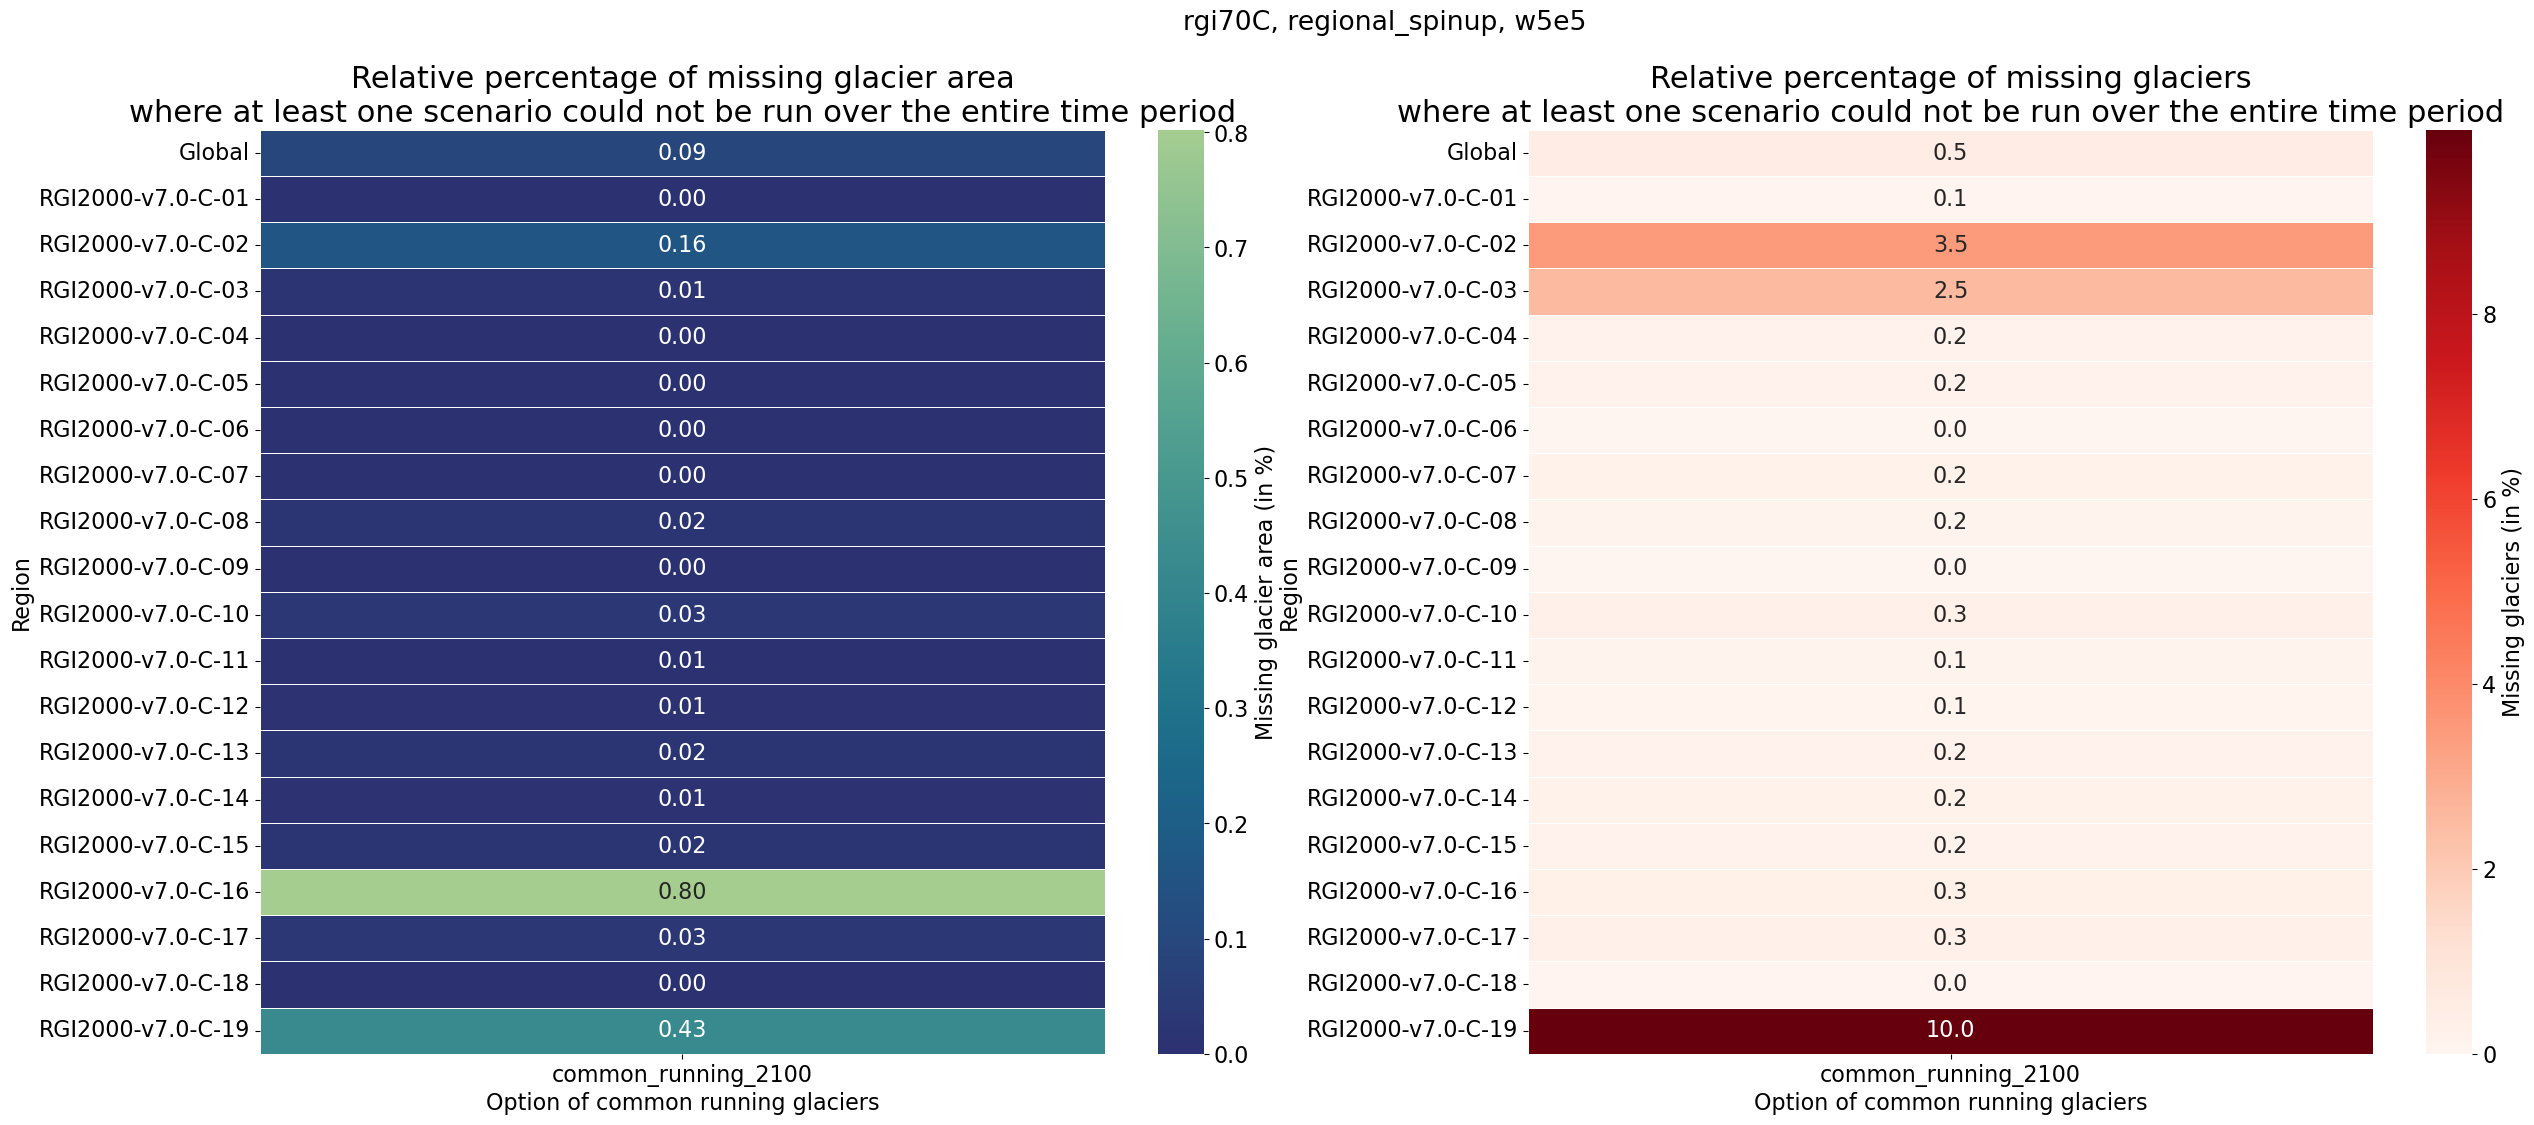

In [36]:
for option in options:
    rgi_version, exp, baseline_climate = option.split('-')
    print(rgi_version, exp, baseline_climate)
    outputpath = _outputpath + f'/{baseline_climate}/{exp}'
    
    odf_2100= pd.read_csv(f'{outputpath}/common_running_2100/missing_region_overview_{rgi_version}{add}.csv', index_col=0)
    odf_2100.loc['Global'] = odf_2100.sum(axis=0)
    # need to recompute the percentage
    odf_2100['missing_area_perc'] = 100*odf_2100['missing_area_km2'] / odf_2100['rgi_area_km2']
    odf_2100['missing_glaciers_perc'] = 100*odf_2100['n_missing_glaciers'] / odf_2100['n_glaciers']
    odf_2100 = odf_2100.sort_index()
    
    
    #odf_2300= pd.read_csv(f'{outputpath}/common_running_2100_2300/missing_region_overview.csv', index_col=0)
    #odf_2300.loc['Global'] = odf_2300.sum(axis=0)
    # need to recompute the percentage
    #odf_2300['missing_area_perc'] = 100*odf_2300['missing_area_km2'] / odf_2300['rgi_area_km2']
    #odf_2300['missing_glaciers_perc'] = 100*odf_2300['n_missing_glaciers'] / odf_2300['n_glaciers']
    #odf_2300 = odf_2300.sort_index()
    
    
    
    import seaborn as sns
    
    odf_area = odf_2100[['missing_area_perc']]
    odf_area.index.name = 'Region'
    odf_area.columns.name = 'Option of common running glaciers'
    odf_area = odf_area.rename(columns={'missing_area_perc':'common_running_2100'})
    #odf_area['common_running_2100_2300'] = odf_2300['missing_area_perc']
    
    odf_glac = odf_2100[['missing_glaciers_perc']]
    odf_glac.index.name = 'Region'
    odf_glac.columns.name = 'Option of common running glaciers'
    odf_glac = odf_glac.rename(columns={'missing_glaciers_perc':'common_running_2100'})
    #odf_glac['common_running_2100_2300'] = odf_2300['missing_glaciers_perc']
    
    
    plt.rc('font', size=16)
    fig, axs = plt.subplots(1,2,figsize=(30,12))
    plt.suptitle(f'{rgi_version}, {exp}, {baseline_climate}')
    ax = axs[0]
    sns.heatmap(odf_area.astype(float), 
                ax=ax,
                annot=True, fmt=".2f",cmap="crest_r",linewidth=.5,
                cbar_kws={'label':'Missing glacier area (in %)'})
    ax.set_title(f'Relative percentage of missing glacier area\nwhere at least one scenario could not be run over the entire time period', fontsize=22)
    
    
    ax = axs[1]
    sns.heatmap(odf_glac.astype(float), annot=True, fmt=".1f",cmap="Reds",linewidth=.5, ax=ax,
                cbar_kws={'label':'Missing glaciers (in %)'})
    ax.set_title(f'Relative percentage of missing glaciers\nwhere at least one scenario could not be run over the entire time period', fontsize=22);
    plt.savefig(f'missing_glacier_area_stats_{option}{add}.png')
